# Modélisation de l'incertitude sur le débit d'eau au niveau de d'exutoires et points d'interets.

Pour cette étude préalable, je considère que le débit d'eau au niveau d'un exutoire/infrastructure sera la somme de l'ensemble des débits des tronçons se rejoignant à l'exutoire.

$$Q_k = \sum_i q_k^i $$

où :
- $Q_k$ est le débit au niveau de l'exutoire étudié.
- $q_k^i$ est le débit du tronçon d'eau juste en avant l'exutoire.

Le debit d'un tronçon à son aval est la somme de son débit en amont + un terme représantant une modification de ce dernier le long du trajet.

$$q_k = \varepsilon_k + \eta_k$$

- $\varepsilon_k$ est le débit au niveau de l'exutoire en amont du tronçon d'eau.
- $\eta_k$ est le terme additif représantant l'augmentation du débit venant de la pluie, de retenues d'eau, drainages, ou autres phénomènes pouvant influencer le niveau d'eau le long du tronçon d'eau.

Ainsi le bassin versant d'un cours d'eau se reconstitue naturellement comme une succession de jonction de tronçon d'eau.

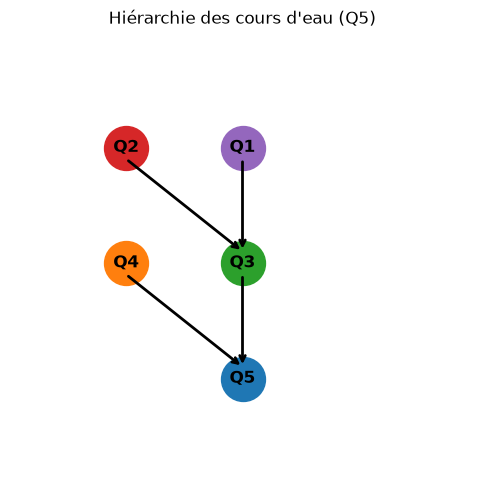

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))

# Positions des noeuds
pos = {
    "Q5": (0, 0),
    "Q4": (-0.5, 0.5),
    "Q3": (0, 0.5),
    "Q2": (-0.5, 1.),
    "Q1": (0, 1.0)
}

# Arêtes (relations)
edges = [
    ("Q4", "Q5"),
    ("Q3", "Q5"),
    ("Q2", "Q3"),
    ("Q1", "Q3")
]

# Dessin des points
for node, (x, y) in pos.items():
    ax.scatter(x, y, s=1000)
    ax.text(x, y, node, ha='center', va='center', fontsize=12, fontweight='bold')

# Dessin des flèches
for start, end in edges:
    x_start, y_start = pos[start]
    x_end, y_end = pos[end]
    # Décalage pour éviter le chevauchement avec le texte 
    y_start -= 0.05
    y_end += 0.05  
    ax.annotate(
        "",
        xy=(x_end, y_end),
        xytext=(x_start, y_start),
        arrowprops=dict(arrowstyle="->", lw=2)
    )

ax.set_xlim(-1, 1)
ax.set_ylim(-0.5, 1.5)
ax.axis("off")

plt.title("Hiérarchie des cours d'eau")
plt.show()

### Mise en donnée aligné avec les standards SIG

In [ ]:
import pandas as pd
import geopandas as gpd

# Création de la dataframe contenant les propriétés des tonçons de cours d'eau
# Ajout d'une propriété NAME pour rendre l'exemple plus clair.
gdf = pd.DataFrame(columns=["HYRIV_ID",
                            "NAME"
                            "NEXT_DOWN",
                            "MAIN_RIV",
                            "LENGTH_KM",
                            "DIST_DN_KM"
                            "DIST_UP_KM",
                            "CATCH_SKM",
                            "UPLAND_SKM"
                            "ENDORHEIC",
                            "DIS_AV_CMS",
                            "ORD_STRA",
                            "ORD_CLAS",
                            "ORD_FLOW",
                            "HYBAS_L12",
                            "Shape_Length",
                            "geometry"])

In [ ]:
# Ajout des prorpiétés des tronçons

